# **Load dataset from Google Drive**
---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Install dependencies & Imports**
---



In [ ]:
!pip install -q scikit-learn gradio joblib

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from math import sqrt
import gradio as gr
import matplotlib.pyplot as plt

# **Importing the Dataset**
---

In [ ]:
dataPath = "/content/drive/MyDrive/AI_Diet_Planner/Dataset/diet_recommendations_dataset.csv"

In [ ]:
df = pd.read_csv(dataPath)
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (1000, 20)


,Patient_ID,Age,Gender,Weight_kg,Height_cm,BMI,Disease_Type,Severity,Physical_Activity_Level,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Dietary_Restrictions,Allergies,Preferred_Cuisine,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score,Diet_Recommendation
0,P0001,56,Male,58.4,160,22.8,Obesity,Moderate,Moderate,3079,173.3,133,116.3,NaN,Peanuts,Mexican,3.1,96.6,3.1,Balanced
1,P0002,69,Male,101.2,169,35.4,Diabetes,Mild,Moderate,3032,199.2,120,137.1,NaN,Peanuts,Chinese,4.5,63.2,0.6,Low_Carb
2,P0003,46,Female,63.5,173,21.2,Hypertension,Mild,Sedentary,1737,181.0,121,109.6,NaN,Peanuts,Chinese,3.8,57.5,4.6,Low_Sodium
3,P0004,32,Male,58.1,164,21.6,NaN,Mild,Moderate,2657,168.2,144,159.4,NaN,NaN,Mexican,4.3,54.5,0.4,Balanced
4,P0005,60,Male,79.5,197,20.5,Diabetes,Moderate,Sedentary,3496,200.4,172,182.3,Low_Sugar,NaN,Italian,9.8,78.2,4.7,Low_Carb


In [ ]:
df

,Patient_ID,Age,Gender,Weight_kg,Height_cm,BMI,Disease_Type,Severity,Physical_Activity_Level,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Dietary_Restrictions,Allergies,Preferred_Cuisine,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score,Diet_Recommendation
0,P0001,56,Male,58.4,160,22.8,Obesity,Moderate,Moderate,3079,173.3,133,116.3,NaN,Peanuts,Mexican,3.1,96.6,3.1,Balanced
1,P0002,69,Male,101.2,169,35.4,Diabetes,Mild,Moderate,3032,199.2,120,137.1,NaN,Peanuts,Chinese,4.5,63.2,0.6,Low_Carb
2,P0003,46,Female,63.5,173,21.2,Hypertension,Mild,Sedentary,1737,181.0,121,109.6,NaN,Peanuts,Chinese,3.8,57.5,4.6,Low_Sodium
3,P0004,32,Male,58.1,164,21.6,NaN,Mild,Moderate,2657,168.2,144,159.4,NaN,NaN,Mexican,4.3,54.5,0.4,Balanced
4,P0005,60,Male,79.5,197,20.5,Diabetes,Moderate,Sedentary,3496,200.4,172,182.3,Low_Sugar,NaN,Italian,9.8,78.2,4.7,Low_Carb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,P0996,18,Male,72.1,160,28.2,Obesity,Moderate,Active,2639,152.6,166,125.1,Low_Sugar,NaN,Mexican,4.4,55.0,3.6,Balanced
996,P0997,35,Female,104.0,171,35.6,Hypertension,Moderate,Moderate,1661,172.2,126,78.6,Low_Sodium,NaN,Chinese,7.3,88.8,2.9,Low_Sodium
997,P0998,49,Female,56.0,182,16.9,Obesity,Severe,Moderate,3102,228.0,148,70.2,Low_Sugar,NaN,Indian,8.9,68.6,4.8,Balanced
998,P0999,64,Male,66.6,185,19.5,Diabetes,Severe,Active,3235,170.1,177,138.0,Low_Sugar,Gluten,Indian,6.7,52.0,0.1,Low_Carb


# **Data Preparation**

### **Setting target column**

In [ ]:
target_col = [c for c in df.columns if 'caloric' in c.lower() or 'calorie' in c.lower()][0]
print("Target column:", target_col)

Target column: Daily_Caloric_Intake


### **Map features**

In [ ]:
col_map = {
    'Weight': [c for c in df.columns if 'weight' in c.lower()][0],
    'Height': [c for c in df.columns if 'height' in c.lower()][0],
    'Disease Type': [c for c in df.columns if 'disease' in c.lower()][0],
    'Gender': [c for c in df.columns if 'gender' in c.lower()][0],
    'Age': [c for c in df.columns if 'age' in c.lower()][0],
    'Physical_Activity_Level': [c for c in df.columns if 'activity' in c.lower()][0]
}

In [ ]:
features = list(col_map.values())
X = df[features].copy()
y = df[target_col].copy()

### **Numeric & categorical features**

In [ ]:
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()
cat_feats = X.select_dtypes(exclude=[np.number]).columns.tolist()

### **Pipelines**

In [ ]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_feats),
    ('cat', cat_pipe, cat_feats)
])

### **Model pipeline**

In [ ]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

### **Split data**

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("Training...")
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_val)

Training...


In [ ]:
mae = mean_absolute_error(y_val, y_pred)
rmse = sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("Train Set Metrics")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

Train Set Metrics
MAE  : 515.485
RMSE : 603.327
R²   : -0.103


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/AI_Diet_Planner/diet_pipeline.pkl"
joblib.dump(pipe, MODEL_PATH)
print("Model saved to:", MODEL_PATH)

Model saved to: /content/drive/MyDrive/AI_Diet_Planner/diet_pipeline.pkl


# **Gradio Web App for Calorie Prediction**

In [ ]:
model = joblib.load(MODEL_PATH)


disease_options = ["None"] + sorted(df['Disease_Type'].dropna().unique().tolist())
activity_options = sorted(df['Physical_Activity_Level'].dropna().unique().tolist())
gender_options = sorted(df['Gender'].dropna().unique().tolist())

def predict_calories(weight, height, disease, gender, age, activity):
    if not weight or not height or not age:
        return "Please provide valid numeric values for Weight, Height, and Age.", "", ""
    if height <= 0:
        return "Height must be greater than zero.", "", ""

    data = pd.DataFrame([{
        'Weight_kg': float(weight),
        'Height_cm': float(height),
        'Disease_Type': str(disease) if disease else 'None',
        'Gender': str(gender) if gender else 'Unknown',
        'Age': float(age),
        'Physical_Activity_Level': str(activity) if activity else 'Moderate'
    }])

    try:
        pred = model.predict(data)[0]
    except Exception as e:
        return f"Model error: {e}", "", ""

    bmi = round(weight / ((height / 100) ** 2), 2)
    if bmi < 18.5:
        tip = "You're underweight. Consider increasing calorie intake with protein-rich foods."
    elif 18.5 <= bmi < 25:
        tip = "You have a healthy BMI. Maintain your balanced diet and regular exercise."
    elif 25 <= bmi < 30:
        tip = "You're overweight. Moderate calorie control and consistent activity recommended."
    else:
        tip = "You're obese. Focus on calorie deficit, lean proteins, and daily walks."

    return f"Predicted Calorie Intake: {pred:.0f} kcal/day", f"BMI: {bmi}", tip

custom_css = """
footer {display: none !important;}

textarea, .gr-textbox textarea {
    font-size: 22px !important;
    line-height: 1.5 !important;
    overflow: hidden !important;
    resize: none !important;
}
"""

demo = gr.Interface(
    fn=predict_calories,
    inputs=[
        gr.Number(label="Weight (kg)", value=70),
        gr.Number(label="Height (cm)", value=170),
        gr.Dropdown(disease_options, label="Disease Type", info="Select if any disease applies"),
        gr.Dropdown(gender_options, label="Gender"),
        gr.Number(label="Age", value=25),
        gr.Dropdown(activity_options, label="Physical Activity Level")
    ],
    outputs=[
        gr.Textbox(label="Predicted Daily Calorie Intake"),
        gr.Textbox(label="BMI"),
        gr.Textbox(label="Health Tip", lines=4)
    ],
    title="AI Diet Planner",
    description="Enter your details to get your predicted daily calorie intake and personalized health tips.",
    css=custom_css,
    flagging_mode="never"
)

demo.launch(share=True, inline=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://87ddd10035386c40ba.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


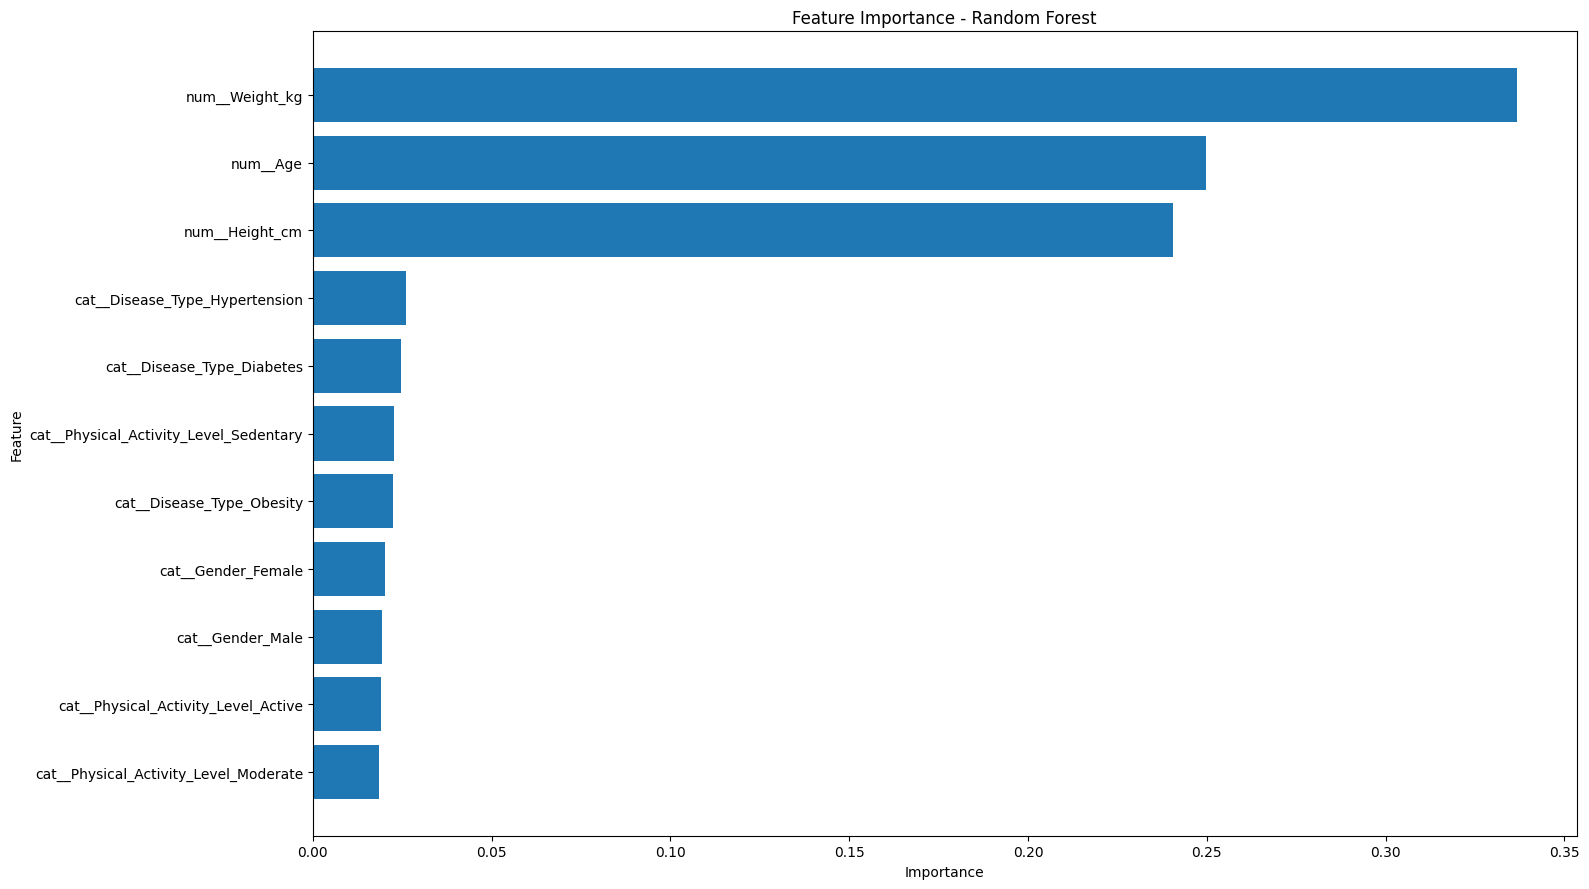

In [ ]:
importances = model.named_steps['model'].feature_importances_
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
sorted_idx = importances.argsort()

plt.figure(figsize=(16, 9))
plt.barh(range(len(importances)), importances[sorted_idx])
plt.yticks(range(len(importances)), feature_names[sorted_idx])
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()